# 01 · Data, quality and demand patterns (NYC yellow taxi, Jan-Jul 2026)

**Stakeholder:** the dispatch / fleet-operations lead of a ride-hailing or taxi fleet.
**Business question:** *Where will passengers be over the next 24 hours, so drivers can be positioned before demand appears?*
**KPIs:** (1) forecast error per zone tier (MAPE / WAPE / RMSE) vs simple baselines; (2) *top-10 hit rate*: does the model's list of the 10 busiest zones in the next 3 h match the truth?; (3) behaviour on holidays and storms.

**Data:** official NYC TLC yellow-taxi trip records (public parquet, 26.4M rows) + TLC zone lookup / shapes + Open-Meteo weather.
All aggregation is done in **DuckDB SQL** directly on the parquet files.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import duckdb, pandas as pd, numpy as np
from IPython.display import Image
from taxidemand import ingest, panel as P, config as C
con = duckdb.connect(); g = ingest.trips_glob()
con.execute(f"DESCRIBE SELECT * FROM read_parquet('{g}')").df()[["column_name", "column_type"]].T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
column_name,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
column_type,INTEGER,TIMESTAMP,TIMESTAMP,BIGINT,DOUBLE,BIGINT,VARCHAR,INTEGER,INTEGER,BIGINT,DOUBLE,DOUBLE,DOUBLE,DOUBLE,DOUBLE,DOUBLE,DOUBLE,DOUBLE,DOUBLE,DOUBLE


### Data quality: why rows are unusable (single SQL pass; first failing rule wins)

In [2]:
q = json.loads((C.ARTIFACTS_DIR / "quality_report.json").read_text())
pd.Series(q["reasons"], name="trips").to_frame().assign(pct=lambda d: (d.trips / q["raw_trips"] * 100).round(2))

,trips,pct
1 pickup time outside the file period (bad timestamp),54,0.00
2 unknown pickup zone (264/265),42487,0.16
3 dropoff not after pickup,328048,1.24
4 negative total amount (refund / dispute),146743,0.56
5 valid trip,25849307,98.04


* 26.37M raw trips → **25.85M valid (98.0%)**.
* 328k trips (1.2%) have a dropoff *not after* the pickup; 147k (0.6%) have a negative total (refunds/disputes); 42k have an unknown pickup zone; 54 have timestamps years outside the file period (e.g. 2001, 2008).
* 802k valid trips (3.1%) have zero distance and 1,036 exceed 100 miles. They are **kept** - they are real pickup events for a *demand* forecast - but flagged in the report.

In [3]:
con.execute(f'''
SELECT strftime(date_trunc('month', tpep_pickup_datetime), '%Y-%m') AS ym, count(*) AS trips,
       round(avg(trip_distance), 2) AS avg_miles, round(avg(total_amount), 2) AS avg_total
FROM read_parquet('{g}')
WHERE tpep_pickup_datetime >= '2026-01-01' AND tpep_pickup_datetime < '2026-08-01'
  AND total_amount >= 0 AND tpep_dropoff_datetime > tpep_pickup_datetime AND PULocationID NOT IN (264, 265)
GROUP BY 1 ORDER BY 1''').df()

,ym,trips,avg_miles,avg_total
0,2026-01,3634087,6.54,29.85
1,2026-02,3327093,6.31,30.62
2,2026-03,3875895,6.04,30.43
3,2026-04,3760961,5.22,30.24
4,2026-05,4017518,4.99,30.70
5,2026-06,3766730,5.24,30.73
6,2026-07,3467023,5.59,30.27


### Demand is concentrated and strongly periodic

top  20 zones:  56.7% of all pickups
top  50 zones:  89.9% of all pickups
top 100 zones:  97.4% of all pickups
top 150 zones:  99.0% of all pickups
110 tail zones average < 1 pickup per hour and are not modelled (use the 4-week average)


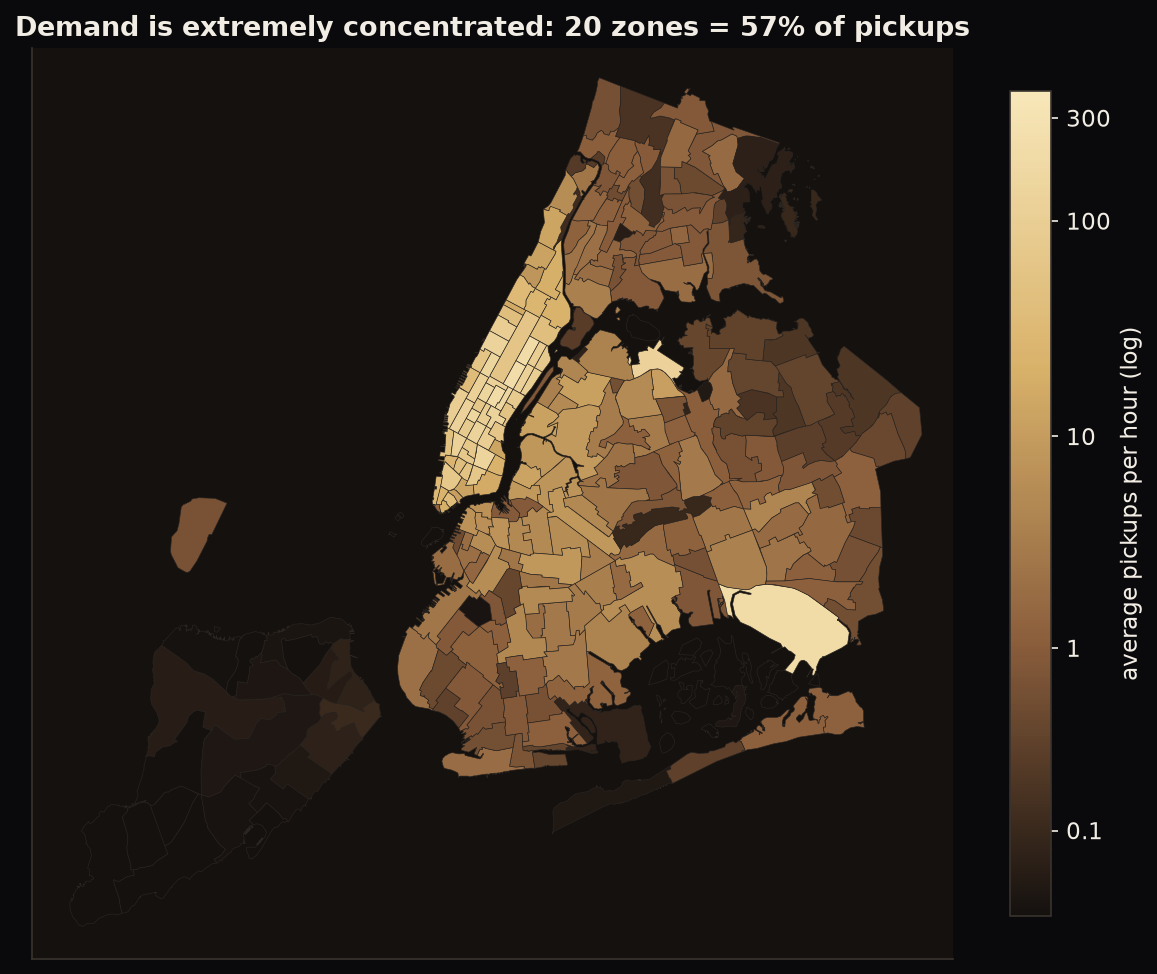

In [4]:
panel = P.panel_from_artifacts()
tot = pd.Series(panel.D[:panel.n_real].sum(0), index=panel.zones).sort_values(ascending=False)
for k in (20, 50, 100, 150):
    print(f"top {k:3d} zones: {tot.iloc[:k].sum() / (np.nansum(panel.city)) * 100:5.1f}% of all pickups")
print(f"{len(panel.tail_zones)} tail zones average < 1 pickup per hour and are not modelled (use the 4-week average)")
Image(str(C.FIGURES_DIR / "02_zone_map.png"))

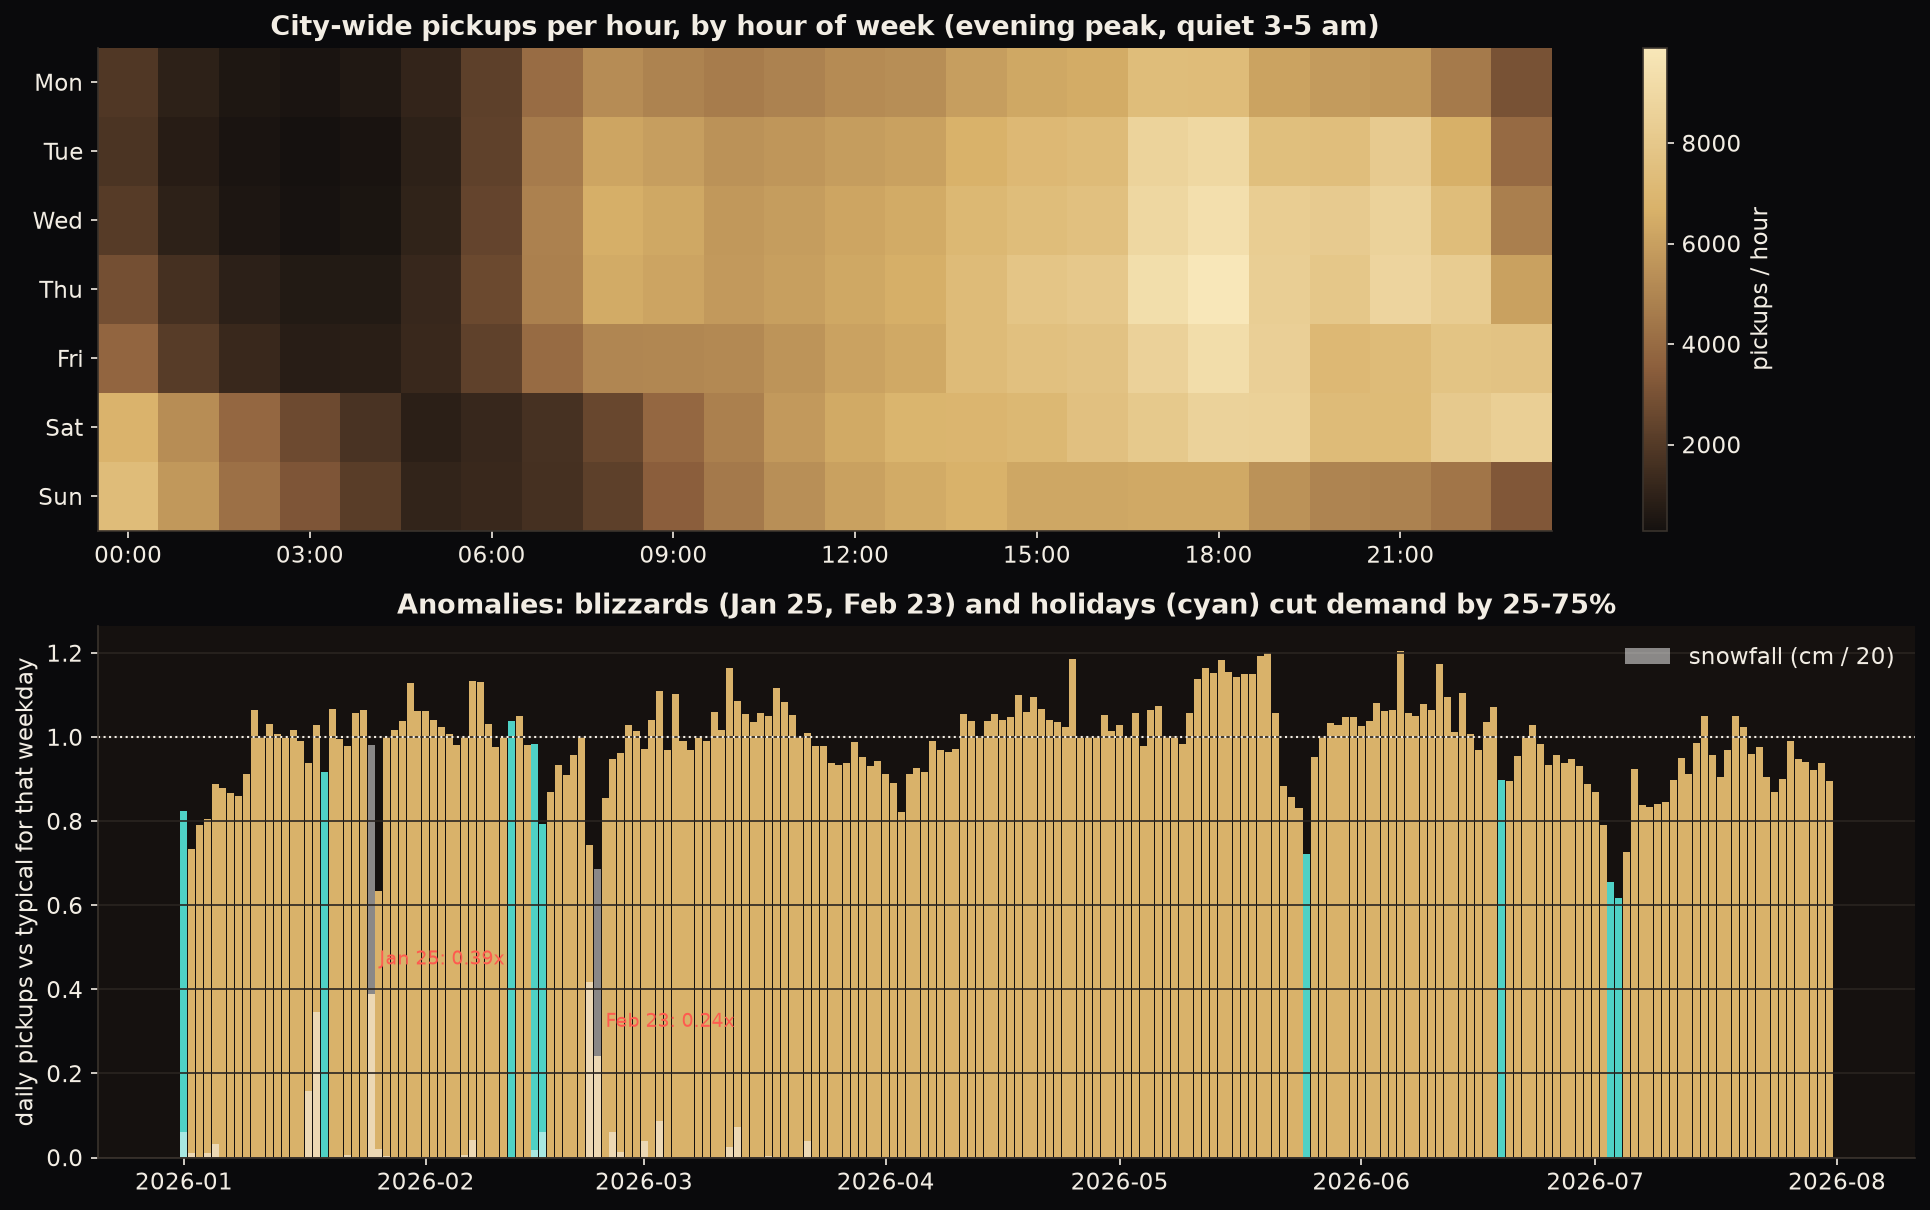

In [5]:
Image(str(C.FIGURES_DIR / "01_demand_patterns.png"))

**Insights that shaped the model**
* **Hour-of-week is the backbone** of demand (evening peak 17-19h Tue-Thu; a late-night peak on Fri/Sat nights), so the strongest baseline is the *average of the same hour-of-week over the previous 4 weeks* and the model predicts the *ratio to that baseline*.
* **Two real blizzards** (Jan 25: 19.6 cm snow, demand ×0.39; Feb 22-23: ×0.74 and ×0.24) and **holidays** (Jul 3-4 ×0.62-0.66, Memorial Day ×0.72) break the weekly pattern. They are kept in the data, given weather and holiday features, and evaluated separately - not deleted.
* **Daylight-saving:** 2026-03-08 has no 02:00 hour. The hourly grid skips it, otherwise a false zero-demand hour would be created.
* The city is 1-2 orders of magnitude more active in Manhattan / airports than elsewhere, so errors are reported **per volume tier**.

In [6]:
d = con.execute(f'''
SELECT PULocationID AS zone, hour(tpep_pickup_datetime) AS hr, count(*) AS trips
FROM read_parquet('{g}') WHERE PULocationID IN (132, 161, 237) AND tpep_pickup_datetime >= '2026-01-01' AND tpep_pickup_datetime < '2026-08-01'
GROUP BY 1, 2''').df().pivot(index="hr", columns="zone", values="trips")
lk = pd.read_csv(C.RAW_DIR / "taxi_zone_lookup.csv").set_index("LocationID").Zone
d.rename(columns=lk.to_dict()).round(0).T

hr,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
zone,,,,,,,,,,,,,,,,,,,,,
JFK Airport,45715,23815,9006,4544,4241,15835,25997,30185,25732,24774,...,61704,72330,76246,65576,60545,70946,73272,68976,68911,62415
Midtown Center,17588,7150,3020,1854,2144,2872,7401,14380,23892,32003,...,67379,70336,80812,94039,97051,85529,86072,85433,66521,37231
Upper East Side South,13071,6040,2825,1741,1564,2472,8006,28857,47132,53179,...,91457,91123,88118,92654,89811,72003,64595,64366,46361,25513


JFK peaks in the afternoon (arrivals) while Midtown and the Upper East Side follow commuting and evening patterns: a global model with zone metadata and per-zone level features can share what is common and still separate these profiles.